## Descriptive Analysis

### 1. Import Packages

In [1]:
import pandas as pd
import re
import nltk
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

In [2]:
import statsmodels.formula.api as smf
from plotnine import *

### 2. Import Dataset

In [217]:
### Drop main that are not in compustat and append a year into one dataframe 
### Declare Path
path_main=Path('/Users/mgor/Documents/Strategy/2YP/Data/data_csv/Skills BGT')
df_skills=pd.DataFrame()

### Select employers that are report on compustat

for file in path_main.glob('*.zip'):
    print(file.name)
    df_aux= pd.read_table(file, encoding='latin')
    #df_aux=df_aux.dropna(subset=['gvkey'])
    df_skills=df_skills.append(df_aux)

Skills_2022-01.zip
Skills_2022-02.zip


In [223]:
df_skills.columns

Index(['BGTJobId', 'JobDate', 'Skill', 'SkillCluster', 'SkillClusterFamily',
       'IsSpecialized', 'IsBaseline', 'IsSoftware', 'Salary'],
      dtype='object')

In [229]:
df_skills.IsSpecialized.unique()

array([0, 1])

In [2]:
### Read dataset
df_2022=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/no_text_2022.zip', delimiter=',', header=0)



/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (33) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [3]:
### Remove repeated columns 
df_2022=df_2022.drop(columns=['JobReferenceID','JobDate_x', 'IsDuplicate','IsDuplicateOf', 'JobId','JobDate_y' ])


In [102]:
### Remove MSA empty
#df_2022 = df_2022[df_2022['MSA'] != -999.0]

In [35]:
### Group
df_aux=df_2022.groupby(['year','month','MSA','Employer','SectorName','OccFam',
       'OccFamName', 'SOC', 'SOCName', 'ONET', 'ONETName','NAICS6',
                        'County', 'State']).mean().reset_index()


In [36]:
len(df_2022)

1547580

In [37]:
len(df_aux)

912743

### 3. Descriptive Statistics

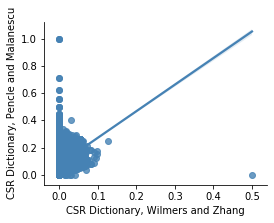

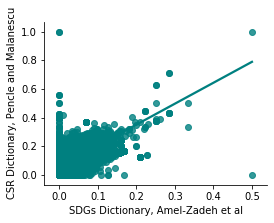

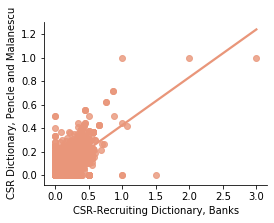

In [100]:
### Correlation among dictionaries

fig, ax = plt.subplots(figsize=(4, 3))
sns.regplot(df_2022['Full_wilzha'],df_2022['CSR'],  'o', color="#4682B4")
plt.ylabel("CSR Dictionary, Pencle and Malanescu")
plt.xlabel("CSR Dictionary, Wilmers and Zhang")
#plt.ylim([0,1])
#plt.xlim([0,.2])
sns.despine()
#plt.savefig('GDP2.pdf', bbox_inches='tight')

fig, ax = plt.subplots(figsize=(4, 3))
sns.regplot(df_2022['SDGs'],df_2022['CSR'],  'o', color="#008080")
plt.ylabel("CSR Dictionary, Pencle and Malanescu")
plt.xlabel("SDGs Dictionary, Amel-Zadeh et al")
#plt.ylim([0,1])
#plt.xlim([0,.2])
sns.despine()
#plt.savefig('GDP2.pdf', bbox_inches='tight')

fig, ax = plt.subplots(figsize=(4, 3))
sns.regplot(df_2022['Recru_sig'],df_2022['CSR'],  'o', color="#E9967A")
plt.ylabel("CSR Dictionary, Pencle and Malanescu")
plt.xlabel("CSR-Recruiting Dictionary, Banks")
#plt.ylim([0,1])
#plt.xlim([0,.2])
sns.despine()
#plt.savefig('GDP2.pdf', bbox_inches='tight')



## Figure XX. CSR across time

In [16]:
## Time series graph

df_aux= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/year.csv.zip', delimiter=',', header=0)
df_aux=df_aux[(df_aux.main_dict_max < 1) ]
sns.set(font_scale=1.5)
sns.set(style='white', font_scale=1.5)


In [17]:
df_temp=df_aux.groupby('year_').mean()

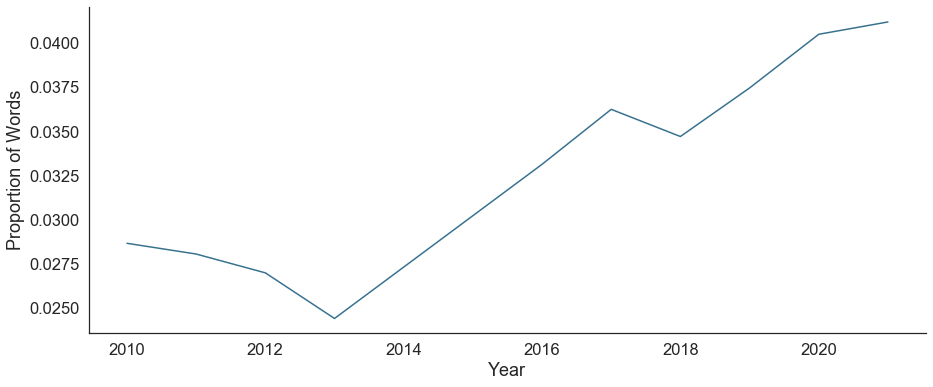

In [18]:
fig, ax = plt.subplots(figsize=(15, 6))
df_temp.main_dict_mean.plot(color="#37718E")


#plt.suptitle('Figure XX: Firms Usage of Prosocial Claims in Job Posts')
#ax.set_title('(Average Per Year)', fontsize=10)
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Words')
sns.despine()
plt.savefig('time.pdf', bbox_inches='tight')

In [185]:
df_temp.main_dict_mean.iloc[0]

0.028652912294819973

In [18]:
df_temp

,main_dict_max,main_dict_min,main_dict_per_90,main_dict_per_10,main_dict_median,main_dict_count,main_dict_mean,main_dict_std,main_dict_max_min,employee_max,...,human_rights_median,human_rights_mean,human_rights_std,human_rights_max_min,soc_com_max,soc_com_min,soc_com_median,soc_com_mean,soc_com_std,soc_com_max_min
year_,,,,,,,,,,,,,,,,,,,,,
2010,0.428931,0.0,0.053338,0.007077,0.025043,211089.416667,0.028653,0.020145,0.428931,0.342515,...,0.014123,0.018163,0.017058,0.336520,0.287157,0.0,0.006750,0.008775,0.009067,0.287157
2011,0.448012,0.0,0.051932,0.006863,0.025033,258207.090909,0.028043,0.019459,0.448012,0.388677,...,0.013664,0.017321,0.016366,0.390327,0.306232,0.0,0.006708,0.008505,0.008924,0.306232
2012,0.328815,0.0,0.049997,0.007520,0.023854,262932.250000,0.026976,0.018446,0.328815,0.278599,...,0.012445,0.015820,0.014874,0.277222,0.163422,0.0,0.006993,0.008702,0.008547,0.163422
2013,0.426984,0.0,0.046380,0.004875,0.021785,377637.500000,0.024386,0.017465,0.426984,0.376407,...,0.010578,0.013664,0.013548,0.356881,0.269382,0.0,0.006161,0.008000,0.008180,0.269382
2016,0.583333,0.0,0.058728,0.009685,0.030849,519530.000000,0.033135,0.020784,0.583333,0.375000,...,0.018034,0.020278,0.016929,0.500000,0.267857,0.0,0.011530,0.012853,0.010939,0.267857
2017,0.666667,0.0,0.063613,0.010067,0.033413,457863.000000,0.036256,0.024453,0.666667,0.500000,...,0.019856,0.023408,0.021157,0.500000,0.500000,0.0,0.013841,0.015346,0.014680,0.500000
2018,0.500000,0.0,0.060302,0.010421,0.032584,647156.500000,0.034715,0.021157,0.500000,0.500000,...,0.019829,0.022445,0.017297,0.500000,0.458333,0.0,0.013565,0.014851,0.011560,0.458333
2019,0.500000,0.0,0.064189,0.012862,0.034884,567438.000000,0.037470,0.021524,0.500000,0.333333,...,0.020915,0.023691,0.017673,0.333333,0.333333,0.0,0.014218,0.015735,0.011764,0.333333
2020,0.492224,0.0,0.070843,0.013801,0.037461,595764.000000,0.040516,0.023349,0.492224,0.378026,...,0.023439,0.027284,0.020442,0.439733,0.294110,0.0,0.015871,0.017611,0.012609,0.294110


In [19]:
df_temp['growth_emp']=(df_temp.employee_mean-df_temp.employee_mean.iloc[0])/df_temp.employee_mean.iloc[0]
df_temp['growth_env']=(df_temp.environment_mean-df_temp.environment_mean.iloc[0])/df_temp.environment_mean.iloc[0]
df_temp['growth_human_rights']=(df_temp.human_rights_mean-df_temp.human_rights_mean.iloc[0])/df_temp.human_rights_mean.iloc[0]
df_temp['growth_soc_com']=(df_temp.soc_com_mean-df_temp.soc_com_mean.iloc[0])/df_temp.soc_com_mean.iloc[0]



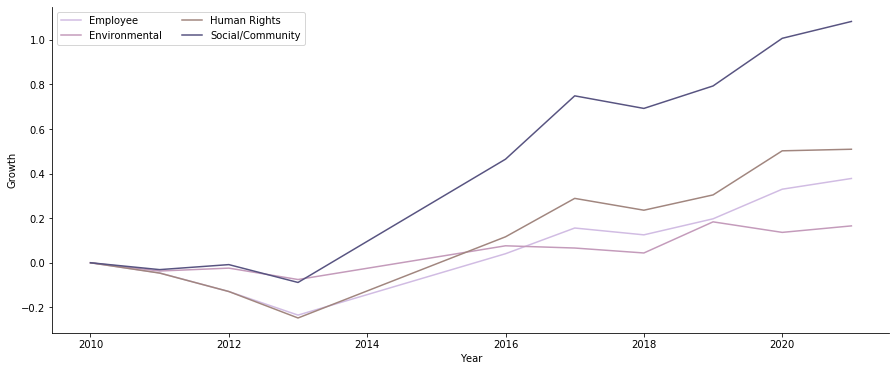

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))
df_temp.growth_emp.plot(color="#D1BCE3", label='Employee')
df_temp.growth_env.plot(color="#C49BBB", label='Environmental')
df_temp.growth_human_rights.plot(color="#A1867F", label='Human Rights')
df_temp.growth_soc_com.plot(color="#585481", label='Social/Community')
#ax.set_title('(2010 Base Year)', fontsize = 10)
#plt.suptitle('Figure XX: Growth in Firms Usage of Prosocial Claims in Job Posts Per Subject')
ax.set_xlabel('Year')
ax.set_ylabel('Growth')
ax.legend(loc='best', fancybox=True, ncol=2)
sns.despine()
plt.savefig('time_decomposed.pdf', bbox_inches='tight')

In [24]:
df_temp

,main_dict_max,main_dict_min,main_dict_per_90,main_dict_per_10,main_dict_median,main_dict_count,main_dict_mean,main_dict_std,main_dict_max_min,employee_max,...,soc_com_max,soc_com_min,soc_com_median,soc_com_mean,soc_com_std,soc_com_max_min,growth_emp,growth_env,growth_human_rights,growth_soc_com
year_,,,,,,,,,,,,,,,,,,,,,
2010,0.428931,0.0,0.053338,0.007077,0.025043,211089.416667,0.028653,0.020145,0.428931,0.342515,...,0.287157,0.0,0.006750,0.008775,0.009067,0.287157,0.000000,0.000000,0.000000,0.000000
2011,0.448012,0.0,0.051932,0.006863,0.025033,258207.090909,0.028043,0.019459,0.448012,0.388677,...,0.306232,0.0,0.006708,0.008505,0.008924,0.306232,-0.045663,-0.037071,-0.046353,-0.030789
2012,0.328815,0.0,0.049997,0.007520,0.023854,262932.250000,0.026976,0.018446,0.328815,0.278599,...,0.163422,0.0,0.006993,0.008702,0.008547,0.163422,-0.129063,-0.024054,-0.129027,-0.008303
2013,0.426984,0.0,0.046380,0.004875,0.021785,377637.500000,0.024386,0.017465,0.426984,0.376407,...,0.269382,0.0,0.006161,0.008000,0.008180,0.269382,-0.234753,-0.075168,-0.247692,-0.088340
2016,0.583333,0.0,0.058728,0.009685,0.030849,519530.000000,0.033135,0.020784,0.583333,0.375000,...,0.267857,0.0,0.011530,0.012853,0.010939,0.267857,0.040587,0.076094,0.116445,0.464676
2017,0.666667,0.0,0.063613,0.010067,0.033413,457863.000000,0.036256,0.024453,0.666667,0.500000,...,0.500000,0.0,0.013841,0.015346,0.014680,0.500000,0.155827,0.066081,0.288788,0.748788
2018,0.500000,0.0,0.060302,0.010421,0.032584,647156.500000,0.034715,0.021157,0.500000,0.500000,...,0.458333,0.0,0.013565,0.014851,0.011560,0.458333,0.125229,0.043907,0.235748,0.692360
2019,0.500000,0.0,0.064189,0.012862,0.034884,567438.000000,0.037470,0.021524,0.500000,0.333333,...,0.333333,0.0,0.014218,0.015735,0.011764,0.333333,0.197148,0.183497,0.304355,0.793169
2020,0.492224,0.0,0.070843,0.013801,0.037461,595764.000000,0.040516,0.023349,0.492224,0.378026,...,0.294110,0.0,0.015871,0.017611,0.012609,0.294110,0.330023,0.136277,0.502165,1.006895


In [223]:
del df_temp
del df_aux

## Growth by sector

In [25]:
df_sec_time= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/sec.csv.zip', delimiter=',', header=0)
df_sec_time=df_sec_time[(df_sec_time.SectorName_ != 'na')]
df_sec_time=df_sec_time[(df_sec_time.main_dict_max < 1) ]



In [26]:
df_sec_time=df_sec_time.groupby(['year_', 'SectorName_']).mean().reset_index()

In [28]:
df_sec_time=df_sec_time.set_index('year_')


In [29]:
df_sec_time['First_Col'] = df_sec_time.groupby('SectorName_')['main_dict_mean'].transform('first')


In [30]:
df_sec_time['Growth']=(df_sec_time['main_dict_mean']-df_sec_time['First_Col'])/df_sec_time['main_dict_mean']

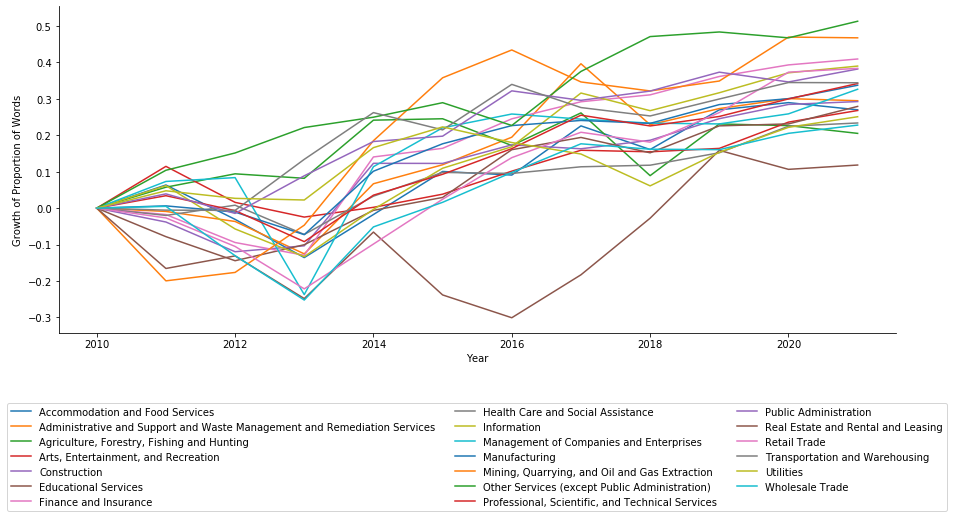

In [32]:
fig, ax = plt.subplots(figsize=(15, 6))
#df_aux.CSR.plot( label="CSR Dictionary", color="#DD8047")

df_sec_time.groupby('SectorName_')['Growth'].plot(legend=True)
#ax.set_title('Figure XX: Growth of Firms Usage of Prosocial Claims in Job Posts, Per Sector')
ax.set_xlabel('Year')
ax.set_ylabel('Growth of Proportion of Words')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),fancybox=True, ncol=3)
sns.despine()
plt.savefig('time_sec.pdf', bbox_inches='tight')

## Growth by Occupation

In [33]:
df_occ_time= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/occ.csv.zip', delimiter=',', header=0)
df_occ_time=df_occ_time[(df_occ_time.OccFamName_ != 'na')]
df_occ_time=df_occ_time[(df_occ_time.main_dict_max < 1) ]


In [34]:
len(df_occ_time)

3006

In [35]:
df_occ_time=df_occ_time.groupby(['year_', 'OccFamName_']).mean().reset_index()


In [36]:
df_occ_time=df_occ_time.set_index('year_')


In [37]:
df_occ_time['First_Col'] = df_occ_time.groupby('OccFamName_')['main_dict_mean'].transform('first')



In [38]:
df_occ_time['Growth']=(df_occ_time['main_dict_mean']-df_occ_time['First_Col'])/df_occ_time['main_dict_mean']

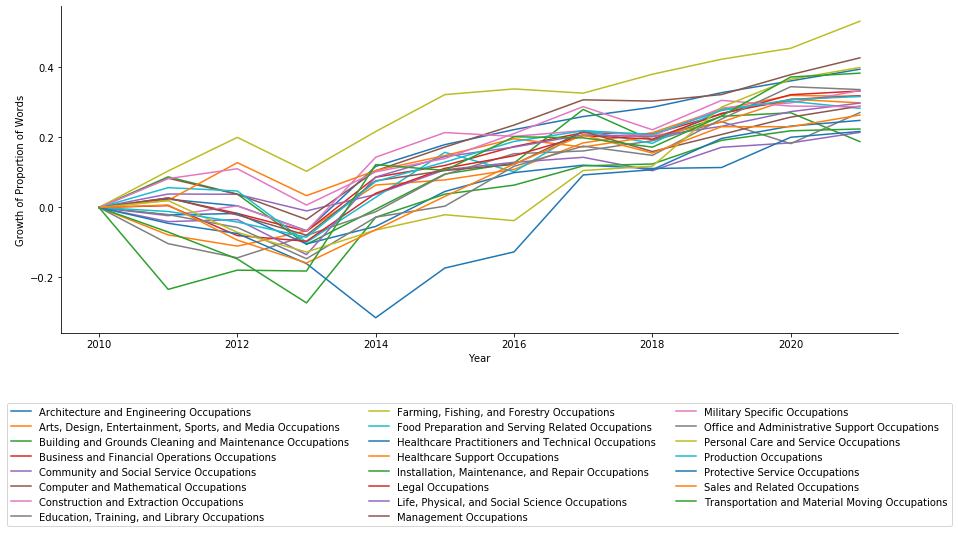

In [40]:
fig, ax = plt.subplots(figsize=(15, 6))
#df_aux.CSR.plot( label="CSR Dictionary", color="#DD8047")

df_occ_time.groupby('OccFamName_')['Growth'].plot(legend=True)
#ax.set_title('Figure XX: Growth of Firms Usage of Prosocial Claims in Job Posts, Per Occupation Families')
ax.set_xlabel('Year')
ax.set_ylabel('Growth of Proportion of Words')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2),fancybox=True, ncol=3)
sns.despine()
plt.savefig('time_occ.pdf', bbox_inches='tight')

## Figure XX. Difference in CSR within firm and occupation across MSAs

In [275]:
df_aux= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_firm.csv.zip', delimiter=',', header=0)


In [60]:
df_aux

,year__,Employer_,OccFamName__,main_dict_max_max,main_dict_min_min,main_dict_count_sum,min_max
0,2010,1-800-FLOWERS.COM,"Arts, Design, Entertainment, Sports, and Media...",0.020492,0.004016,10,0.016476
1,2010,1-800-FLOWERS.COM,Business and Financial Operations Occupations,0.046512,0.000000,10,0.046512
2,2010,1-800-FLOWERS.COM,Computer and Mathematical Occupations,0.030000,0.000000,16,0.030000
4,2010,1-800-FLOWERS.COM,"Life, Physical, and Social Science Occupations",0.030568,0.013793,2,0.016775
5,2010,1-800-FLOWERS.COM,Management Occupations,0.034934,0.002427,37,0.032507
...,...,...,...,...,...,...,...
434665,2021,ZYNGA INC,Management Occupations,0.067847,0.000000,168,0.067847
434666,2021,ZYNGA INC,Office and Administrative Support Occupations,0.063584,0.000000,10,0.063584
434667,2021,ZYNGA INC,Personal Care and Service Occupations,0.061611,0.056433,2,0.005178
434668,2021,ZYNGA INC,Sales and Related Occupations,0.064789,0.007380,38,0.057409


In [62]:
### Differences across MSA within the same firm within the same occupation
df_aux= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_firm.csv.zip', delimiter=',', header=0)
#df_aux=df_aux[(df_aux.main_dict_count_sum != 1) ]
#df_aux=df_aux[(df_aux.main_dict_max_max < 1) ]
#df_aux=df_aux[(df_aux.Employer__ != 'na') ]

In [63]:
df_aux=df_aux.rename(columns={"Employer_": "name_bgt"})
df_aux=df_aux.merge(name_comp, how='left', on='name_bgt')
df_aux=df_aux.rename(columns={ "name_compustat":"Employer" })

df_aux=df_aux[(df_aux.Employer != 'na')]
df_aux=df_aux[(df_aux.main_dict_max < 1) ]



In [64]:
df_aux=df_aux.groupby(['year_', 'Employer', 'OccFamName_']).agg(({'main_dict_max':['max'],
                                                 'main_dict_min':['min'],
                                                 'main_dict_count':['sum']})).reset_index()
df_aux.columns=['_'.join(col) if type(col) is tuple else col for col in df_aux.columns.values]

In [57]:
df_aux=df_aux[(df_aux.main_dict_count_sum != 1) ]
df_aux=df_aux[(df_aux.main_dict_max_max < 1) ]

In [58]:
df_aux['min_max']=df_aux['main_dict_max_max']-df_aux['main_dict_min_min']

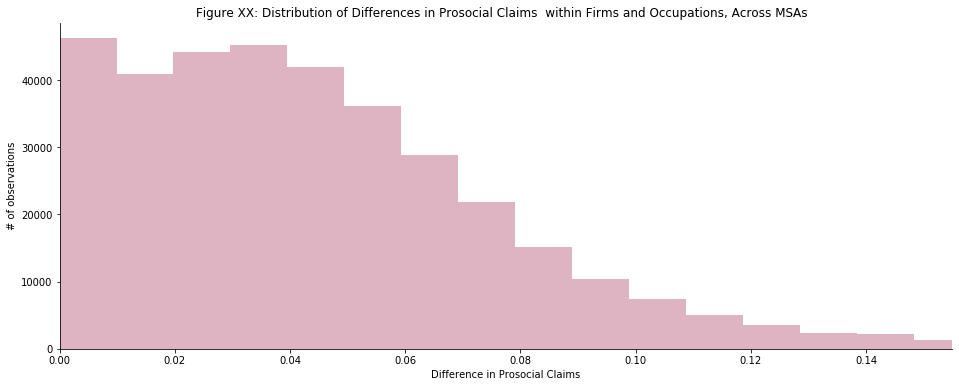

In [59]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_aux['min_max'], bins=100,  color='#d8a1b3', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.155])
ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims  within Firms and Occupations, Across MSAs  ')

sns.despine()
plt.savefig('msa_dist.pdf', bbox_inches='tight')

In [282]:
df_aux.min_max.describe()

count    727487.000000
mean          0.038209
std           0.046394
min           0.000000
25%           0.012215
50%           0.028409
75%           0.050111
max           0.988924
Name: min_max, dtype: float64

In [61]:
del df_aux

## Figure XX. Difference in CSR within firms across occupations and MSAs

In [29]:
df_firm= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_firm.csv.zip', delimiter=',', header=0)


In [31]:
df_firm=df_firm.rename(columns={"Employer_": "name_bgt"})



In [34]:
df_firm=df_firm.merge(name_comp, how='left', on='name_bgt')


In [35]:
df_firm=df_firm.rename(columns={ "name_compustat":"Employer" })


In [36]:
df_firm=df_firm[(df_firm.Employer != 'na')]
df_firm=df_firm[(df_firm.main_dict_max < 1) ]

In [39]:
df_firm_aux=df_firm.groupby(['year_', 'Employer']).agg(({'main_dict_mean':['mean']})).reset_index()
df_firm_aux.columns=['_'.join(col) if type(col) is tuple else col for col in df_firm_aux.columns.values]

In [47]:
df_firm_aux

,year__,Employer_,main_dict_mean_mean
0,2010,1-800-FLOWERS.COM,0.018983
1,2010,21ST CENTURY ONCOLOGY HLDGS,0.051853
2,2010,3D SYSTEMS CORP,0.014902
3,2010,3M CO,0.025302
4,2010,8X8 INC,0.007613
...,...,...,...
39142,2021,ZUORA INC,0.028222
39143,2021,ZYLA LIFE SCIENCES,0.047847
39144,2021,ZYMEWORKS INC,0.072569
39145,2021,ZYNEX INC,0.031828


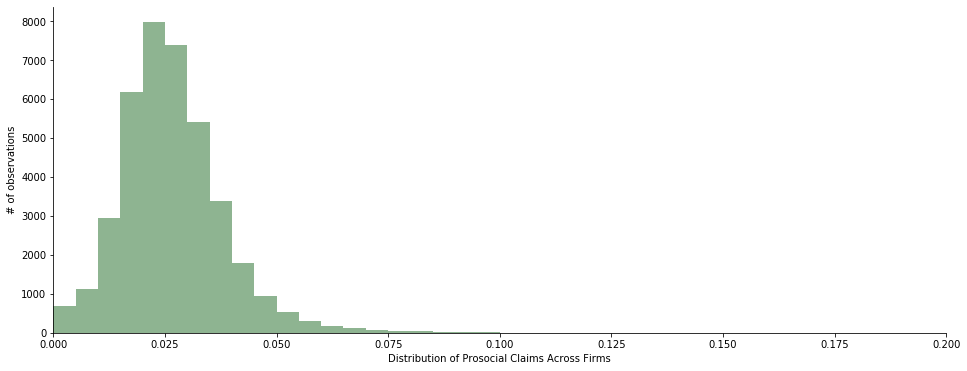

In [75]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_firm_aux['main_dict_mean_mean'], bins=100,  color='#72A276', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Distribution of Prosocial Claims Across Firms')
ax.set_xlim([0,.2])

sns.despine()
plt.savefig('firm_dist.pdf', bbox_inches='tight')

In [34]:
df_firm=df_firm.groupby(['year_', 'Employer']).agg(({'main_dict_max':['max'],
                                                 'main_dict_min':['min'],
                                                 'main_dict_count':['sum']})).reset_index()
df_firm.columns=['_'.join(col) if type(col) is tuple else col for col in df_firm.columns.values]

In [36]:
df_firm=df_firm.rename(columns={"year__": "year", "Employer_":"Employer", "main_dict_max_max": "max","main_dict_min_min": "min", "main_dict_count_sum": "count"}, errors="raise")


In [39]:
df_firm['min_max']=df_firm['max']-df_firm['min']

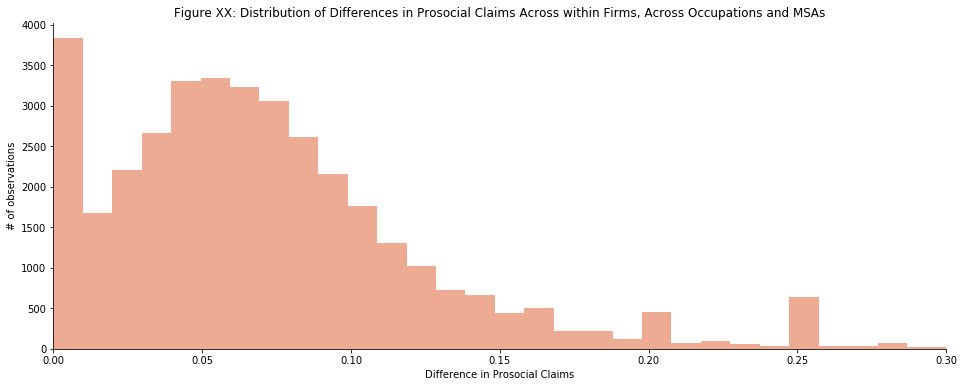

In [42]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_firm['min_max'], bins=100,  color='#E9967A', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.3])
ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims Across within Firms, Across Occupations and MSAs'  )

sns.despine()
plt.savefig('firm.pdf', bbox_inches='tight')

In [43]:
df_firm.min_max.describe()

count    39147.000000
mean         0.095884
std          0.109167
min          0.000000
25%          0.037505
50%          0.066986
75%          0.105614
max          0.988924
Name: min_max, dtype: float64

In [44]:
del df_firm

## Figure XX. Differences within occupations and across firms 

In [62]:
df_soc= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_soc.csv.zip', delimiter=',', header=0)


In [64]:
df_soc=df_soc[(df_soc.main_dict_count != 1) ]

df_soc=df_soc[(df_soc.main_dict_max < 1) ]

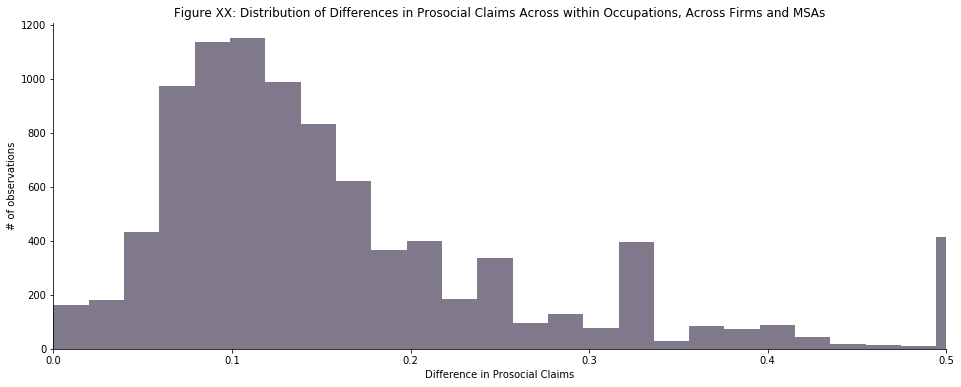

In [68]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_soc['main_dict_max_min'], bins=50,  color='#605770', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.5])
ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims Across within Occupations, Across Firms and MSAs'  )


sns.despine()
plt.savefig('soc_dist.pdf', bbox_inches='tight')

In [200]:
df_soc.min_max.describe()

count    8491.000000
mean        0.219550
std         0.141347
min         0.000000
25%         0.130435
50%         0.181132
75%         0.261794
max         0.937500
Name: min_max, dtype: float64

## Figure XX. Occupation Family

In [118]:
#df_occ= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/occ.csv.zip', delimiter=',', header=0)



In [258]:
df_occ=df_occ_time.reset_index()



In [260]:
df_occ=df_occ.groupby(['OccFamName_']).mean().reset_index().sort_values(by=['main_dict_mean'])



In [205]:
#df_occfam=df_occ.groupby(['OccFamName']).mean().sort_values(by=['main_dict'])

In [261]:
#df_occfam=df_occfam.reset_index()
df_occ=df_occ[(df_occ.OccFamName_ != 'na')]


In [262]:
df_occ=df_occ.set_index(['OccFamName_'])

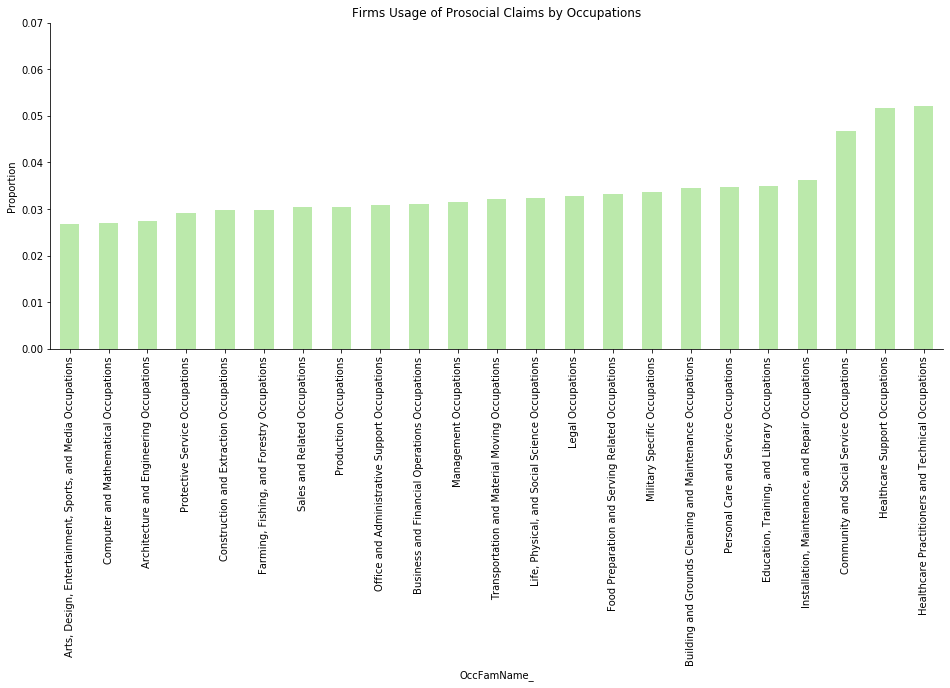

In [268]:
df_occ['main_dict_mean'].plot(kind="bar",figsize = (16,6), title='Firms Usage of Prosocial Claims by Occupations', color=["#bbe9ab"])
plt.ylabel('Proportion')
plt.ylim((0,.07))

sns.despine()
plt.savefig('byocc.pdf', bbox_inches='tight')

In [270]:
del df_occ

In [256]:
df_degree= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_deg.csv.zip', delimiter=',', header=0)



In [258]:
df_degree=df_degree[(df_degree.Degree != 'na')]
df_degree=df_degree[(df_degree.Employer != 'na')]
df_degree=df_degree[(df_degree.max_csr < 1) ]
df_degree=df_degree[(df_degree.count_csr != 1) ]

In [266]:
df_degree['min_max']=df_degree['max_csr']-df_degree['min_csr']


In [294]:
df_temp=df_degree[(df_degree.Degree!= "Bachelor's") ]

In [280]:
df_temp2=df_degree[(df_degree.Degree!= "High School") ]

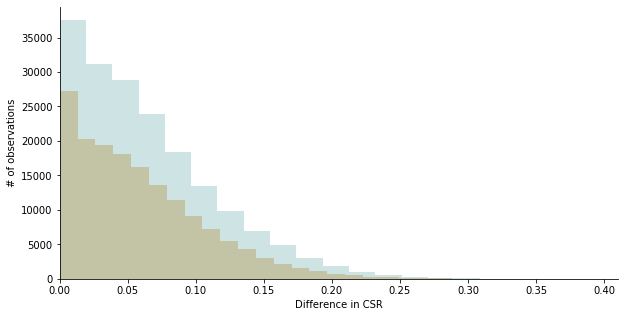

In [305]:
fig, ax = plt.subplots(1,1, figsize=(10, 5))

ax.hist(df_temp['min_max'], bins=50,  color='#EDCB96', alpha=1, label= "Minimum Bachelor's Degree")
ax.hist(df_temp2['min_max'], bins=50,  color='#86BBBD', alpha=.4, label= "Minimum Highshool")
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in CSR')
ax.set_xlim([0,.41])
#ax.set_title('Figure XX: Distribution of Proportion of CSR Across Job Posts ')

sns.despine()
plt.savefig('soc_dist.pdf', bbox_inches='tight')

In [307]:
dty_pivots = df_degree.pivot_table(index='Employer', columns='Degree', values='min_max')

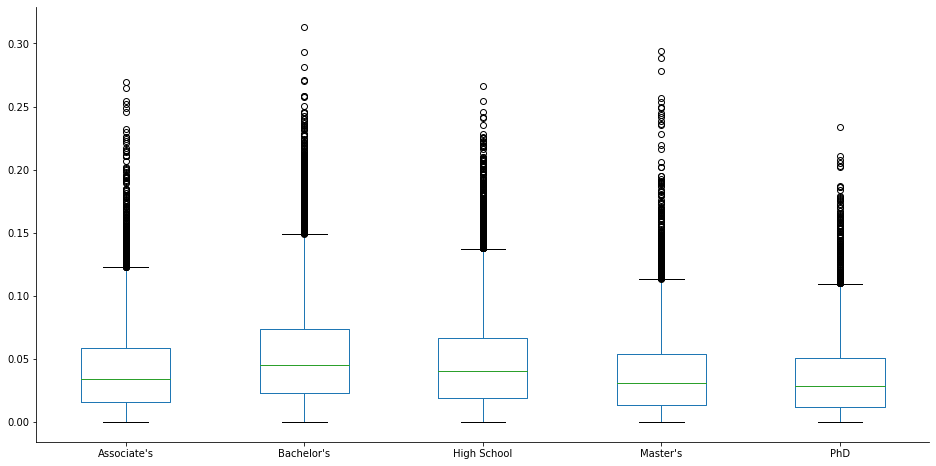

In [311]:
dty_pivots.plot(kind='box', figsize=[16,8])
#plt.title('Figure 15: Distribution of murder rate by year')
#plt.xlabel("Year")
#plt.ylabel("Rate")
sns.despine()
plt.savefig('Figure6.pdf', bbox_inches='tight')

In [19]:
df_skill= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/spec.csv.zip', delimiter=',', header=0)
df_skill=df_skill[(df_skill.main_dict_mean_mean < 1) ]

In [22]:
df_skill=df_skill.rename(columns={"Employer__": "name_bgt"})
df_skill=df_skill.merge(name_comp, how='left', on='name_bgt')
df_skill=df_skill.rename(columns={ "name_compustat":"Employer" })

In [23]:
df_skill=df_skill.groupby(['year__','Employer']).mean()

In [24]:
df_skill.IsSpecialized_mean_mean.describe()

count    38959.000000
mean         0.986342
std          0.058066
min          0.000000
25%          0.995695
50%          1.000000
75%          1.000000
max          1.000000
Name: IsSpecialized_mean_mean, dtype: float64

In [25]:
df_skill=df_skill[(df_skill.IsSpecialized_mean_mean > .6) ]

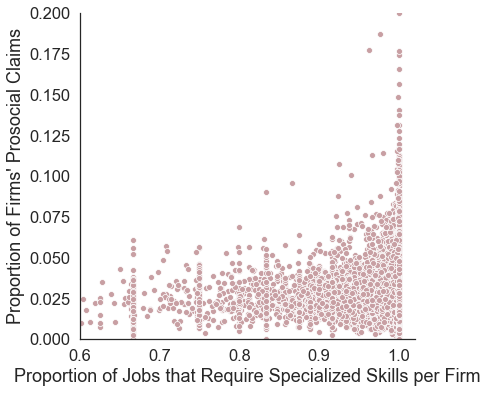

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(df_skill['IsSpecialized_mean_mean'],df_skill['main_dict_mean_mean'], color="#C89FA3")
#sns.regplot(df_skill['IsSpecialized_mean_mean'],df_skill['main_dict_mean_mean'], scatter = False, ci = 0, color="#EFB0A1")


plt.ylabel("Proportion of Firms' Prosocial Claims")
plt.xlabel("Proportion of Jobs that Require Specialized Skills per Firm")
plt.ylim([0,.20])
plt.xlim([.6,1.02])
sns.despine()
plt.savefig('skills.pdf', bbox_inches='tight')

## Differences per MSA

In [48]:
df_msa= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/diff_msa.csv.zip', delimiter=',', header=0)



In [49]:
df_msa

,year,MSA,max_csr,min_csr,p25_csr,p75_csr,p905_csr,p10_csr,count_csr
0,2010,-999.0,0.500000,0.000000,0.031546,0.071429,0.098281,0.010526,231680.0
1,2010,10100.0,0.170213,0.000000,0.027778,0.059184,0.087127,0.000000,714.0
2,2010,10140.0,0.189474,0.000000,0.039735,0.076087,0.107143,0.029836,340.0
3,2010,10180.0,0.231707,0.000000,0.031915,0.072243,0.096364,0.019011,3210.0
4,2010,10220.0,0.180851,0.000000,0.036869,0.067386,0.094879,0.026495,552.0
...,...,...,...,...,...,...,...,...,...
11143,2021,49660.0,0.291667,0.000000,0.065307,0.121283,0.151163,0.048544,16384.0
11144,2021,49700.0,0.303797,0.000000,0.053459,0.098444,0.126928,0.040296,4272.0
11145,2021,49740.0,0.286667,0.000000,0.057546,0.107354,0.144828,0.040201,3824.0
11146,2021,49780.0,0.246795,0.006944,0.066316,0.117679,0.157895,0.050595,2286.0


In [129]:
df_msa=df_msa[(df_msa.count_csr != 1) ]
df_msa=df_msa[(df_msa.MSA != -999.0)]
df_msa=df_msa[(df_msa.max_csr < 1) ]

In [130]:
df_msa['min_max']=df_msa['max_csr']-df_msa['min_csr']

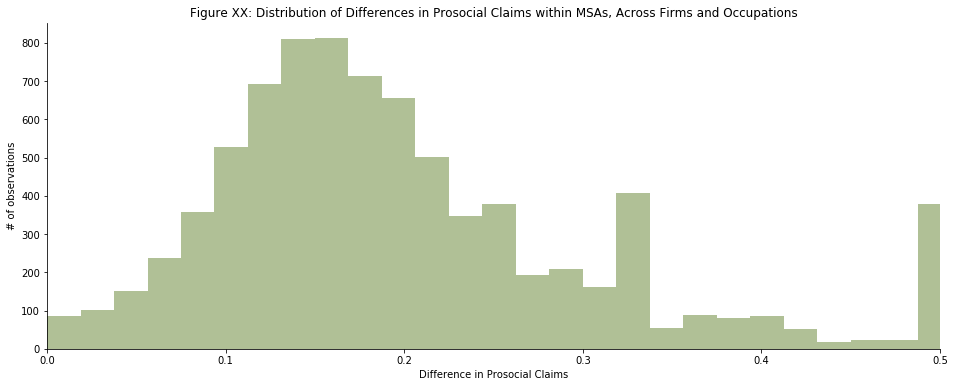

In [133]:
fig, ax = plt.subplots(1,1, figsize=(16, 6))
ax.hist(df_soc['min_max'], bins=50,  color='#9DB17C', alpha=.8)
ax.set_ylabel('# of observations')
ax.set_xlabel('Difference in Prosocial Claims')
ax.set_xlim([0,.5])
ax.set_title('Figure XX: Distribution of Differences in Prosocial Claims within MSAs, Across Firms and Occupations'  )


sns.despine()
plt.savefig('msa_dist.pdf', bbox_inches='tight')

## Labor

In [21]:
## Merge compustat
name_comp= pd.read_stata('/Users/mgor/Documents/Strategy/2YP/Data/data_csv/Labor/compustat_bg_names_dedupl.dta')


In [214]:
name_comp

,name_bgt,name_compustat,gvkey,compustat_year1,compustat_year2,subsidiary_compustat,subsidiary_name_compustat,headquarter_state_compustat
0,99 Restaurants,CANNAE HOLDINGS INC,020960,2013.0,2018.0,1.0,"99 Restaurants, LLC",Nevada
1,Acorda Therapeutics Incorporated,ACORDA THERAPEUTICS INC,156617,2001.0,2018.0,1.0,Acorda Therapeutics Limited,New York
2,Airt,AIR T INC,001210,1982.0,2018.0,1.0,AIR T,North Carolina
3,American Biltrite Incorporated,AMERICAN BILTRITE INC,001397,1960.0,2018.0,1.0,American Biltrite Ltd,Massachusetts
4,"Amyris, Inc",AMYRIS INC,184717,2005.0,2018.0,0.0,AMYRIS INC,California
...,...,...,...,...,...,...,...,...
32699,Zynerba Pharmaceuticals,ZYNERBA PHARMACEUTICALS INC,025128,2013.0,2018.0,0.0,ZYNERBA PHARMACEUTICALS INC,Pennsylvania
32700,Zynex Medical,ZYNEX INC,129441,1999.0,2018.0,1.0,"Zynex Medical, Inc",Colorado
32701,"Zynex Medical, Inc",ZYNEX INC,129441,1999.0,2018.0,1.0,"Zynex Medical, Inc",Colorado
32702,Zynex Medical Inc,ZYNEX INC,129441,1999.0,2018.0,1.0,"Zynex Medical, Inc",Colorado


### Test main

In [724]:
df_exm= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/main1.csv.zip', delimiter=',', header=0)


/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,49,50,51,52,53,54,57,58,59,61,64,65,72,73,74,75) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [725]:
df_exm=df_exm.rename(columns={"Employer": "name_bgt"})
df_exm=df_exm.merge(name_comp, how='left', on='name_bgt')
df_exm=df_exm.rename(columns={ "name_compustat":"Employer" })

df_exm=df_exm.groupby(['year','month' ,'Employer','gvkey', 'BestFitMSA','MSA','FIPS']).agg(({'main_dict':['mean']})).reset_index()
df_exm.columns=['_'.join(col) if type(col) is tuple else col for col in df_exm.columns.values]

In [407]:
df_exm=df_exm.replace('na', -999)


In [408]:
df_exm['BestFitMSA_'] = df_exm['BestFitMSA_'].astype(float, errors = 'raise')



In [390]:
df_exm=df_exm[(df_exm.BestFitMSA_!= 'na') ]



In [409]:
df_unem=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_csv/Labor/unemp.csv', delimiter=',', header=0)
df_unem=df_unem.dropna(how='all')
df_unem=df_unem.rename(columns={"Year": "year_", "Month":"month_", "Area FIPS Code":"BestFitMSA_"}, errors="raise")


/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (9) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [410]:
df_exm=df_exm.merge(df_unem, how='left', on=['year_', 'month_', 'BestFitMSA_'], indicator=True)


### Unemployment

In [27]:
df_tt= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/graphunem.csv.zip', delimiter=',', header=0)



In [28]:
df_tt=df_tt[(df_tt._merge == 'both') ].sort_values('Unemployment Rate')

In [29]:
df_tt=df_tt.groupby(['year_','month_', 'MSA_']).mean().reset_index()

In [30]:
df_tt=df_tt[(df_tt.main_dict_mean < .08) ]

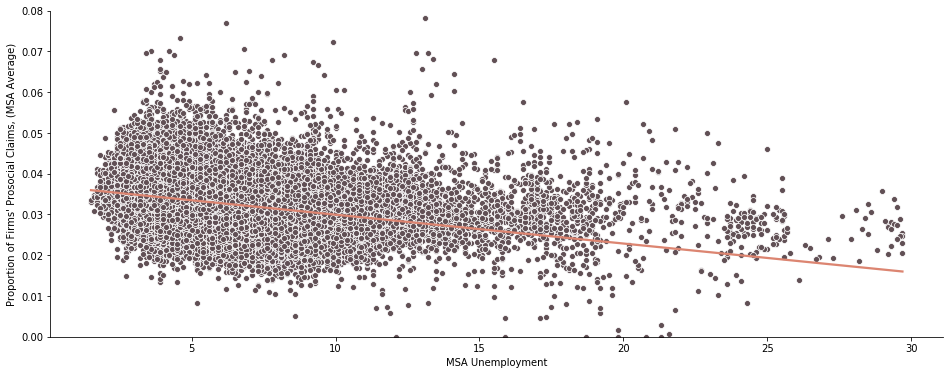

In [569]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.scatterplot(df_tt['Unemployment Rate'],df_tt['main_dict_mean'], color="#615055")
sns.regplot(df_tt['Unemployment Rate'],df_tt['main_dict_mean'], scatter = False, ci = 0, color="#DC8571")

plt.ylabel("Proportion of Firms' Prosocial Claims, (MSA Average)")
plt.xlabel("MSA Unemployment")
plt.ylim([0,.08])
#plt.xlim([0,30])
sns.despine()
plt.savefig('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/unem_msa.pdf', bbox_inches='tight')


## Compustat

In [180]:
df_compustat= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_csv/compustat_data_clean.csv', delimiter=',', header=0)
df_exm= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/sum01.csv.zip', delimiter=',', header=0)



In [183]:
df_exm = df_exm.add_suffix('_sum')

In [184]:
df_exm.columns

Index(['year_sum', 'month_sum', 'Employer_sum', 'gvkey_sum', 'MSA_sum',
       'Unnamed: 0_sum', 'BGTJobId_sum', 'IsDuplicate_sum',
       'IsDuplicateOf_sum', 'length_sum', 'Freq_sum', 'Rel_Freq_sum',
       'Full_wilzha_sum', 'career_meaning_sum', 'worklife_meaning_sum',
       'SDGs_sum', 'CSR_sum', 'main_dict_sum', 'employee_sum',
       'environment_sum', 'human_rights_sum', 'soc_com_sum', 'NAICS3_sum',
       'NAICS4_sum', 'NAICS5_sum', 'NAICS6_sum', 'FIPSState_sum', 'Lat_sum',
       'Lon_sum', 'Edu_sum', 'MaxEdu_sum', 'Exp_sum', 'MaxExp_sum',
       'MinSalary_sum', 'MaxSalary_sum', 'MinHrlySalary_sum',
       'MaxHrlySalary_sum', 'Internship_sum',
       'occ_Architecture and Engineering Occupations_sum',
       'occ_Arts, Design, Entertainment, Sports, and Media Occupations_sum',
       'occ_Building and Grounds Cleaning and Maintenance Occupations_sum',
       'occ_Business and Financial Operations Occupations_sum',
       'occ_Community and Social Service Occupations_sum',


In [731]:
df_exm=df_exm.rename(columns={"Employer": "name_bgt"})
df_exm=df_exm.merge(name_comp, how='left', on='name_bgt')
df_exm=df_exm.rename(columns={ "name_compustat":"Employer" })



In [733]:

df_exm.loc[df_exm['month'] < 4, 'quarter'] = 1
df_exm.loc[(df_exm['month'] > 3) & (df_exm['month'] < 7), 'quarter'] = 2
df_exm.loc[(df_exm['month'] > 6) & (df_exm['month'] < 10), 'quarter'] = 3
df_exm.loc[(df_exm['month'] > 9) & (df_exm['month'] < 13), 'quarter'] = 4



In [734]:
df_exm=df_exm.groupby(['year','quarter' ,'Employer','gvkey']).agg(({'main_dict':['mean']})).reset_index()
df_exm.columns=['_'.join(col) if type(col) is tuple else col for col in df_exm.columns.values]

In [740]:
df_exm=df_exm.rename(columns={ "year_":'year', "gvkey_":"gvkey","quarter_":"quarter"}, errors="raise")



In [745]:
df_exm.gvkey = df_exm.gvkey.astype(int, errors = 'raise')



In [746]:
df_exm2=df_exm.merge(df_compustat, how='left', on=['gvkey','year','quarter'])



In [13]:
df_exm= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/comp_tot.csv.zip', delimiter=',', header=0)



In [14]:
df_exm.roe.describe()

count    6.059440e+05
mean              NaN
std               NaN
min              -inf
25%     -1.682395e-02
50%      2.198283e-02
75%      4.996558e-02
max               inf
Name: roe, dtype: float64

In [15]:
df_exm=df_exm[(df_exm.main_dict_mean < .2) ]

In [39]:
df_exm=df_exm[(df_exm.gprofit !=0) ]
df_exm=df_exm[(df_exm.roe <10) ]
df_exm=df_exm[(df_exm.roe >-10) ]

In [17]:
df_exm

,year,quarter,Employer_,gvkey,main_dict_mean,Unnamed: 0,datadate,indfmt,consol,popsrc,...,roe,meq,tonbiq,mlev,rd_at,cash_at,gprofit,tang,capxq,capx_at
0,2010,1.0,1-800-FLOWERS.COM,122519,0.010497,135389.0,20090930.0,INDL,C,D,...,-0.057157,238.796476,1.305402,0.346814,NaN,0.009912,0.126257,0.175968,2.489303,0.007601
2,2010,1.0,3D SYSTEMS CORP,14898,0.018823,49189.0,20100331.0,INDL,C,D,...,0.018569,341.784284,2.330928,0.026147,0.016281,0.173466,0.093620,0.164432,0.276953,0.001651
3,2010,1.0,3M CO,7435,0.045980,23835.0,20100331.0,INDL,C,D,...,0.068554,64976.041447,2.642463,0.088390,0.012205,0.164407,0.111710,0.244772,171.187304,0.005603
5,2010,1.0,A. H. BELO CORP,179288,0.024906,174479.0,20100331.0,INDL,C,D,...,-0.029091,163.214555,0.585605,0.000000,NaN,0.128220,-0.020216,0.491398,0.864659,0.002003
6,2010,1.0,AAON INC,21542,0.038256,68960.0,20100331.0,INDL,C,D,...,0.042120,422.519946,2.660724,0.000137,NaN,0.158010,0.077012,0.380977,3.847898,0.022033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709233,2021,3.0,ZUMIEZ INC,162988,0.025230,156107.0,20211031.0,INDL,C,D,...,0.057739,823.495869,1.426647,0.230886,0.000000,0.345624,0.145903,0.344241,2.864403,0.003375
709234,2021,3.0,ZUORA INC,33232,0.031376,104133.0,20211031.0,INDL,C,D,...,-0.127357,2397.609083,7.019151,0.022052,0.050645,0.473733,0.142515,0.175251,1.983881,0.005327
709235,2021,3.0,ZYMEWORKS INC,31059,0.070729,99299.0,20210930.0,INDL,C,D,...,-0.217184,1173.034290,3.552572,0.021845,0.118691,0.732127,-0.121539,0.102612,4.454567,0.012213
709236,2021,3.0,ZYNEX INC,129441,0.025127,138291.0,20210930.0,INDL,C,D,...,0.096351,343.675012,4.667254,0.047103,NaN,0.389846,0.323732,0.219404,0.052235,0.000664


In [38]:
df_exm=df_exm[df_exm['roe'].notna()]
df_exm=df_exm[df_exm['main_dict_mean'].notna()]

(-10, 10)

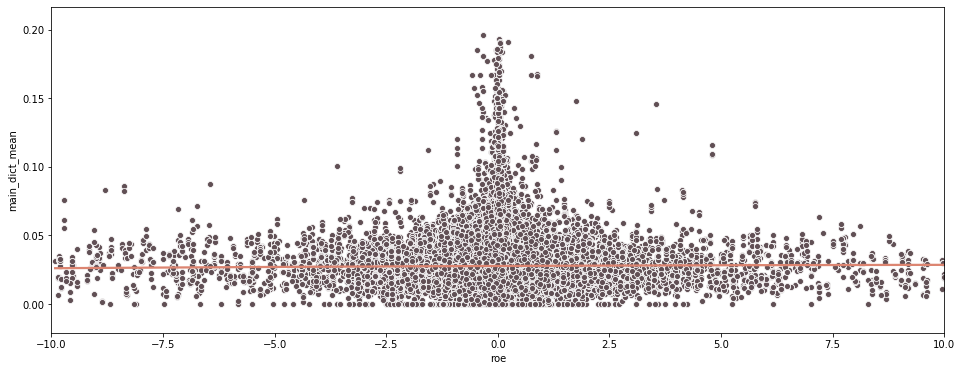

In [25]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.scatterplot(df_exm['roe'],df_exm['main_dict_mean'], color="#615055")

sns.regplot(df_exm['roe'],df_exm['main_dict_mean'], scatter=False,ci = None, order=2, color="#DC8571")
#plt.ylim([0,.2])
plt.xlim([-10,10])

In [31]:
from binsreg import binsregselect, binsreg, binsqreg, binsglm, binstest, binspwc


def binscatter(**kwargs):
    # Estimate binsreg
    est = binsreg(**kwargs)
    
    # Retrieve estimates
    df_est = pd.concat([d.dots for d in est.data_plot])
    df_est = df_est.rename(columns={'x': kwargs.get("x"), 'fit': kwargs.get("y")})
    
    # Add confidence intervals
    if "ci" in kwargs:
        df_est = pd.merge(df_est, pd.concat([d.ci for d in est.data_plot]))
        df_est = df_est.drop(columns=['x'])
        df_est['ci'] = df_est['ci_r'] - df_est['ci_l']
    
    # Rename groups
    if "by" in kwargs:
        df_est['group'] = df_est['group'].astype(df[kwargs.get("by")].dtype)
        df_est = df_est.rename(columns={'group': kwargs.get("by")})

    return df_est

In [33]:
# Estimate binsreg

#df_graph=df_exm[df_exm['gprofit'].notna()]
#df_graph=df_exm[df_exm['gprofit'].notna()]

df_est = binscatter(x='Unemployment Rate', y='main_dict_mean', data=df_tt)


In [22]:
df_est2=binsreg(x='roe', y='main_dict_mean', nbins=15, ci=(3,3),
                vce="HC1", polyreg=2,asyvar=True,data=df_exm)

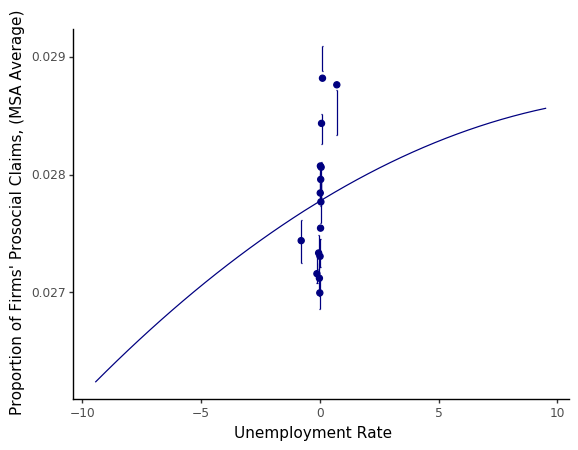

<ggplot: (8785706096569)>

In [23]:
df_est2.bins_plot+theme_classic()+labs(x='Unemployment Rate', y="Proportion of Firms' Prosocial Claims, (MSA Average)", size=5)


In [30]:
df_est3=binsreg(x='Unemployment Rate', y='main_dict_mean', nbins=20,   ci=(2,2),
                vce="HC1", asyvar=True, data=df_tt)

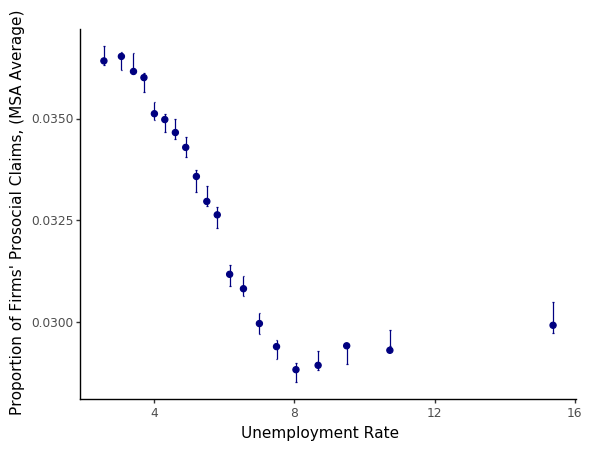

<ggplot: (8785748238681)>

In [34]:
df_est3.bins_plot+theme_classic()+labs(x='Unemployment Rate', y="Proportion of Firms' Prosocial Claims, (MSA Average)", size=(6,6))




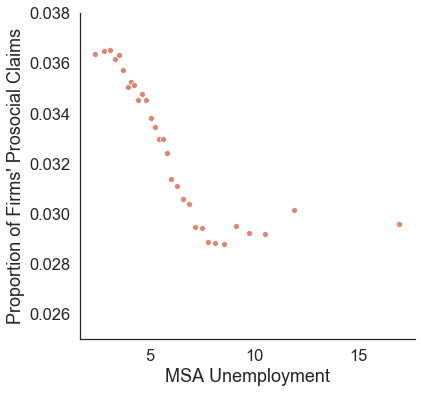

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x='Unemployment Rate', y='main_dict_mean', data=df_est, color="#DC8571");
#plt.errorbar('Unemployment Rate', 'main_dict_mean', data=df_est, color="#DC8571");
plt.ylabel("Proportion of Firms' Prosocial Claims")
plt.xlabel("MSA Unemployment")
plt.ylim([.025,.038])
sns.despine()
plt.savefig('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/unem_binned2.png', bbox_inches='tight')



In [223]:
df_main= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/main1.csv.zip', delimiter=',', header=0)



/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3331: DtypeWarning: Columns (53,54) have mixed types.Specify dtype option on import or set low_memory=False.


In [229]:
df_main.columns

Index(['Unnamed: 0', 'BGTJobId', 'CanonEmployer', 'JobReferenceID',
       'JobDate_x', 'IsDuplicate', 'IsDuplicateOf', 'length', 'WordFreq',
       'MostCom', 'ComWord', 'Freq', 'Rel_Freq', 'Full_wilzha',
       'career_meaning', 'worklife_meaning', 'SDGs', 'CSR', 'main_dict',
       'employee', 'environment', 'human_rights', 'soc_com', 'year', 'month',
       'JobId', 'JobDate_y', 'CleanTitle', 'CanonTitle', 'OccFam',
       'OccFamName', 'SOC', 'SOCName', 'ONET', 'ONETName', 'Specialty',
       'BGTOcc', 'BGTOccName', 'BGTOccGroupName', 'BGTOccGroupName2',
       'BGTCareerAreaName', 'BGTCareerAreaName2', 'Employer', 'Sector',
       'SectorName', 'NAICS3', 'NAICS4', 'NAICS5', 'NAICS6', 'City', 'State',
       'County', 'FIPSState', 'FIPSCounty', 'FIPS', 'Lat', 'Lon', 'BestFitMSA',
       'BestFitMSAName', 'BestFitMSAType', 'MSA', 'MSAName', 'Edu', 'MaxEdu',
       'Degree', 'MaxDegree', 'Exp', 'MaxExp', 'MinSalary', 'MaxSalary',
       'MinHrlySalary', 'MaxHrlySalary', 'PayFrequenc

In [231]:
df_main.groupby(['MSA','BestFitMSA']).mean()


Unnamed: 0      BGTJobId  IsDuplicate  IsDuplicateOf  \
MSA    BestFitMSA                                                            
-999   70750        68514.675676  3.831892e+10          0.0            0.0   
       71050        58881.333333  3.831861e+10          0.0            0.0   
       71350        62822.500000  3.831898e+10          0.0            0.0   
       72250        78373.000000  3.831805e+10          0.0            0.0   
       72400        76251.684211  3.831869e+10          0.0            0.0   
...                          ...           ...          ...            ...   
 49660 49660        70866.451890  3.831867e+10          0.0            0.0   
 49700 49700        66703.132743  3.831887e+10          0.0            0.0   
 49740 49740        65782.790541  3.831829e+10          0.0            0.0   
 49780 49780        69552.644860  3.831856e+10          0.0            0.0   
 49820 49820       116931.250000  3.831775e+10          0.0            0.0   

                       length       Freq  Rel_Freq  Full_wilzha  \
MSA    BestFitMSA                                                 
-999   70750       241.297297   8.405405  0.042328     0.003568   
       71050       229.000000   7.833333  0.052346     0.001801   
       71350       139.500000   4.000000  0.069843     0.000000   
       72250        18.750000   2.250000  0.121726     0.000000   
       72400       371.631579   9.605263  0.032433     0.000034   
...                       ...        ...       ...          ...   
 49660 49660       291.699313   9.118557  0.038428     0.001664   
 49700 49700       302.460177   9.407080  0.036008     0.002966   
 49740 49740       324.695946  10.040541  0.037391     0.002963   
 49780 49780       311.457944   9.504673  0.038152     0.001788   
 49820 49820       253.187500   8.937500  0.048104     0.001296   

                   career_meaning  worklife_meaning  ...         Lon  \
MSA    BestFitMSA                                    ...               
-999   70750             0.000956          0.000266  ...  -68.351949   
       71050             0.001825          0.000000  ...  -72.576400   
       71350             0.000000          0.000000  ...  -72.873600   
       72250             0.000000          0.000000  ...  -69.692600   
       72400             0.002925          0.000000  ...  -73.270668   
...                           ...               ...  ...         ...   
 49660 49660             0.001131          0.000024  ...  -80.633536   
 49700 49700             0.001164          0.000052  ... -121.531186   
 49740 49740             0.001920          0.000040  ... -114.618162   
 49780 49780             0.000836          0.000000  ...  -81.992309   
 49820 49820             0.000833          0.000000  ...  -99.263100   

                          Edu      MaxEdu         Exp      MaxExp  \
MSA    BestFitMSA                                                   
-999   70750      -479.108108 -889.432432 -647.500000 -944.891892   
       71050      -999.000000 -999.000000 -999.000000 -999.000000   
       71350      -999.000000 -999.000000 -999.000000 -999.000000   
       72250      -999.000000 -999.000000 -999.000000 -999.000000   
       72400      -172.394737 -784.736842 -260.458421 -390.888158   
...                       ...         ...         ...         ...   
 49660 49660      -626.864261 -837.142612 -679.015464 -945.548110   
 49700 49700      -613.787611 -891.380531 -529.232301 -910.318584   
 49740 49740      -691.121622 -862.040541 -694.466216 -971.898649   
 49780 49780      -554.299065 -885.373832 -727.721963 -905.327103   
 49820 49820      -745.750000 -935.812500 -623.843750 -936.250000   

                     MinSalary    MaxSalary  MinHrlySalary  MaxHrlySalary  \
MSA    BestFitMSA                                                           
-999   70750       -999.000000  -999.000000    -999.000000    -999.000000   
       71050       -999.000000  -999.000000    -999.000000    -999.00

In [148]:
df_main.OccFamName=df_main.OccFamName.replace({'na': 'Not defined', np.nan:'Not defined'})

In [149]:
df_main.SectorName=df_main.SectorName.replace({'na': 'Not defined', np.nan:'Not defined'})

In [150]:
df_main=pd.get_dummies(df_main
               ,columns = ['OccFamName']
               ,prefix = 'occ')
df_main=pd.get_dummies(df_main
               ,columns = ['SectorName']
               ,prefix = 'sector')

In [129]:
df_degree= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/Degree_2018-01.zip', encoding='latin')



In [ ]:
df_degree=df_degree.drop(columns=[ 'JobDate', 'Salary'])
df_degree=df_degree.groupby(['BGTJobId']).min().reset_index()

In [132]:
df_degree=pd.get_dummies(df_degree
               ,columns = ['DegreeLevel']
               ,prefix = 'deg')

In [134]:
df_skills= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/Skills_2018-01.zip', encoding='latin')



In [135]:
df_skills=df_skills.drop(columns=[ 'JobDate', 'Skill', 'SkillCluster', 'SkillClusterFamily', 'Salary'])


In [137]:
df_skills=df_skills.groupby(['BGTJobId']).mean().reset_index()


In [139]:
df_degree=df_degree.merge(df_skills, how='left', on='BGTJobId')

In [140]:
df_degree

,BGTJobId,deg_12,deg_13,deg_16,deg_18,deg_21,IsSpecialized,IsBaseline,IsSoftware
0,38314358549,0,0,1,0,0,0.800000,0.200000,0.000000
1,38314358550,0,0,1,0,0,0.800000,0.200000,0.000000
2,38314358557,0,0,0,1,0,0.615385,0.384615,0.000000
3,38314358562,0,0,1,0,0,0.714286,0.285714,0.000000
4,38314358571,1,0,0,0,0,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
1166106,38323207813,0,0,1,0,0,0.722222,0.277778,0.500000
1166107,38323207817,0,0,1,0,0,0.909091,0.090909,0.636364
1166108,38323207832,1,0,0,0,0,0.000000,1.000000,0.000000
1166109,38323207839,0,0,1,0,0,0.733333,0.266667,0.133333


In [151]:
df_main=df_main.merge(df_degree, how='left', on='BGTJobId')

In [155]:
df_main=df_main.rename(columns={"Employer": "name_bgt"})
df_main=df_main.merge(name_comp, how='left', on='name_bgt')
df_main=df_main.rename(columns={ "name_compustat":"Employer" })

In [170]:
df_collapsed=df_main.groupby(['Employer','year','month']).mean()

In [166]:
df_main['total_posts']=1

In [168]:
df_testd=df_main.groupby(['year','month','Employer']).agg(({'total_posts':['count'],
                                                                'IsSpecialized':['mean']})).reset_index()

In [171]:
df_main=df_main.merge(df_testd, how='left', on='Employer')


/opt/anaconda3/lib/python3.7/site-packages/pandas/core/generic.py:4150: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.


In [173]:
df_main.columns.tolist()

['Unnamed: 0',
 'BGTJobId',
 'CanonEmployer',
 'JobReferenceID',
 'JobDate_x',
 'IsDuplicate',
 'IsDuplicateOf',
 'length',
 'WordFreq',
 'MostCom',
 'ComWord',
 'Freq',
 'Rel_Freq',
 'Full_wilzha',
 'career_meaning',
 'worklife_meaning',
 'SDGs',
 'CSR',
 'main_dict',
 'employee',
 'environment',
 'human_rights',
 'soc_com',
 'year',
 'month',
 'JobId',
 'JobDate_y',
 'CleanTitle',
 'CanonTitle',
 'OccFam',
 'SOC',
 'SOCName',
 'ONET',
 'ONETName',
 'Specialty',
 'BGTOcc',
 'BGTOccName',
 'BGTOccGroupName',
 'BGTOccGroupName2',
 'BGTCareerAreaName',
 'BGTCareerAreaName2',
 'name_bgt',
 'Sector',
 'NAICS3',
 'NAICS4',
 'NAICS5',
 'NAICS6',
 'City',
 'State',
 'County',
 'FIPSState',
 'FIPSCounty',
 'FIPS',
 'Lat',
 'Lon',
 'BestFitMSA',
 'BestFitMSAName',
 'BestFitMSAType',
 'MSA',
 'MSAName',
 'Edu',
 'MaxEdu',
 'Degree',
 'MaxDegree',
 'Exp',
 'MaxExp',
 'MinSalary',
 'MaxSalary',
 'MinHrlySalary',
 'MaxHrlySalary',
 'PayFrequency',
 'SalaryType',
 'JobHours',
 'TaxTerm',
 'Internshi

In [200]:
df_aux= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/comp2010.csv.zip', delimiter=',', header=0)


In [241]:
df_tt=df_tt.drop(columns=['Unnamed: 0_x',
 'BGTJobId_x','IsDuplicate_x', 'month_x','IsDuplicateOf_x', 'length_x','Freq_x','Rel_Freq_x','NAICS3_x','NAICS4_x','NAICS5_x',
 'NAICS6_x','FIPSState_x','Lat_x','Lon_x','Edu_x','MaxEdu_x', 'MaxExp_x','Internship_x','compustat_year1_x',
 'compustat_year2_x','subsidiary_compustat_x','Employer_y','month_y','Unnamed: 0_y','BGTJobId_y',
 'IsDuplicate_y','IsDuplicateOf_y','length_y','Freq_y','Rel_Freq_y','Full_wilzha_y',
 'career_meaning_y','worklife_meaning_y','SDGs_y','CSR_y','main_dict_y','employee_y','environment_y','human_rights_y',
 'soc_com_y','NAICS3_y','NAICS4_y','NAICS5_y','NAICS6_y','FIPSState_y','Lat_y','Lon_y','Edu_y','MaxEdu_y',
 'Exp_y','MaxExp_y','MinSalary_y','MaxSalary_y','MinHrlySalary_y','MaxHrlySalary_y','Internship_y','compustat_year1_y',
 'compustat_year2_y','subsidiary_compustat_y','Unnamed: 0'])

In [244]:
df_tt=df_tt.rename(columns={ 'Employer_x':"employer",
 'Full_wilzha_x':'full_wilzha',
 'career_meaning_x': 'career_mean','worklife_meaning_x':'work_mean','SDGs_x':'sdgs','CSR_x':'csr','main_dict_x':'prosocial',
 'employee_x':'employee','environment_x':'environ','human_rights_x':'hum_rig','soc_com_x':'soc_com',
 'Exp_x':'exp','MinSalary_x':'min_wage',
 'MaxSalary_x':'max_wage','MinHrlySalary_x':'min_hour_wage','MaxHrlySalary_x':'max_hour_wage',
 'occ_Architecture and Engineering Occupations_x':'occ_arch_mean',
 'occ_Arts, Design, Entertainment, Sports, and Media Occupations_x':'occ_art_mean',
 'occ_Building and Grounds Cleaning and Maintenance Occupations_x':'occ_clean_mean',
 'occ_Business and Financial Operations Occupations_x':'occ_bus_mean',
 'occ_Community and Social Service Occupations_x':'occ_soc_com_mean',
 'occ_Computer and Mathematical Occupations_x':'occ_math_mean',
 'occ_Construction and Extraction Occupations_x':'occ_constr_mean',
 'occ_Education, Training, and Library Occupations_x':'occ_educ_mean',
 'occ_Farming, Fishing, and Forestry Occupations_x':'occ_farm_mean',
 'occ_Food Preparation and Serving Related Occupations_x':'occ_food_mean',
 'occ_Healthcare Practitioners and Technical Occupations_x':'occ_health_prac_mean',
 'occ_Healthcare Support Occupations_x':'occ_health_sup_mean',
 'occ_Installation, Maintenance, and Repair Occupations_x':'occ_inst_mean',
 'occ_Legal Occupations_x':'occ_legal_mean',
 'occ_Life, Physical, and Social Science Occupations_x':'occ_sci_mean',
 'occ_Management Occupations_x':'occ_manage_mean',
 'occ_Military Specific Occupations_x':'occ_mil_mean',
 'occ_Not defined_x':'occ_not_defined_mean',
 'occ_Office and Administrative Support Occupations_x':'occ_off_adm_mean',
 'occ_Personal Care and Service Occupations_x':'occ_care_mean',
 'occ_Production Occupations_x':'occ_prod_mean',
 'occ_Protective Service Occupations_x':'occ_protec_mean',
 'occ_Sales and Related Occupations_x':'occ_sales_mean',
 'occ_Transportation and Material Moving Occupations_x':'occ_trans_mean',
 'occ_Architecture and Engineering Occupations_y':'occ_arch_sum',
 'occ_Arts, Design, Entertainment, Sports, and Media Occupations_y':'occ_art_sum',
 'occ_Building and Grounds Cleaning and Maintenance Occupations_y':'occ_clean_sum',
 'occ_Business and Financial Operations Occupations_y':'occ_bus_sum',
 'occ_Community and Social Service Occupations_y':'occ_soc_com_sum',
 'occ_Computer and Mathematical Occupations_y':'occ_math_sum',
 'occ_Construction and Extraction Occupations_y':'occ_constr_sum',
 'occ_Education, Training, and Library Occupations_y':'occ_educ_sum',
 'occ_Farming, Fishing, and Forestry Occupations_y':'occ_farm_sum',
 'occ_Food Preparation and Serving Related Occupations_y':'occ_food_sum',
 'occ_Healthcare Practitioners and Technical Occupations_y':'occ_health_prac_sum',
 'occ_Healthcare Support Occupations_y':'occ_health_sup_sum',
 'occ_Installation, Maintenance, and Repair Occupations_y':'occ_inst_sum',
 'occ_Legal Occupations_y':'occ_legal_sum',
 'occ_Life, Physical, and Social Science Occupations_y':'occ_sci_sum',
 'occ_Management Occupations_y':'occ_manage_sum',
 'occ_Military Specific Occupations_y':'occ_mil_sum',
 'occ_Not defined_y':'occ_not_defined_sum',
 'occ_Office and Administrative Support Occupations_y':'occ_off_adm_sum',
 'occ_Personal Care and Service Occupations_y':'occ_care_sum',
 'occ_Production Occupations_y':'occ_prod_sum',
 'occ_Protective Service Occupations_y':'occ_protec_sum',
 'occ_Sales and Related Occupations_y':'occ_sales_sum',
 'occ_Transportation and Material Moving Occupations_y':'occ_trans_sum',
 'sector_Accommodation and Food Services_x':'sec_accom_food_mean',
 'sector_Administrative and Support and Waste Management and Remediation Services_x':'sec_adm_wast_mean',
 'sector_Agriculture, Forestry, Fishing and Hunting_x':'sec_agric_mean',
 'sector_Arts, Entertainment, and Recreation_x':'sec_arts_mean',
 'sector_Construction_x':'sec_const_mean',
 'sector_Educational Services_x':'sec_educ_mean',
 'sector_Finance and Insurance_x':'sec_finan_mean',
 'sector_Health Care and Social Assistance_x':'sec_health_mean',
 'sector_Information_x':'sec_inf_mean',
 'sector_Management of Companies and Enterprises_x':'sec_manage_mean',
 'sector_Manufacturing_x':'sec_manu',
 'sector_Mining, Quarrying, and Oil and Gas Extraction_x':'sec_mini_mean',
 'sector_Not defined_x':'sec_not_defined_mean',
 'sector_Other Services (except Public Administration)_x':'sec_serv_nonpub_mean',
 'sector_Professional, Scientific, and Technical Services_x':'sec_prof_serv_mean',
 'sector_Public Administration_x':'sec_pub_adm_mean',
 'sector_Real Estate and Rental and Leasing_x':'sec_realest_mean',
 'sector_Retail Trade_x':'sec_retail_mean',
 'sector_Transportation and Warehousing_x':'sec_trans_mean',
 'sector_Utilities_x':'sec_util_mean',
 'sector_Wholesale Trade_x':'sec_whole_mean',
 'sector_Accommodation and Food Services_y':'sec_accom_food_sum',
 'sector_Administrative and Support and Waste Management and Remediation Services_y':'sec_adm_wast_sum',
 'sector_Agriculture, Forestry, Fishing and Hunting_y':'sec_agric_sum',
 'sector_Arts, Entertainment, and Recreation_y':'sec_arts_sum',
 'sector_Construction_y':'sec_const_sum',
 'sector_Educational Services_y':'sec_educ_sum',
 'sector_Finance and Insurance_y':'sec_finan_sum',
 'sector_Health Care and Social Assistance_y':'sec_health_sum',
 'sector_Information_y':'sec_inf_sum',
 'sector_Management of Companies and Enterprises_y':'sec_manage_sum',
 'sector_Manufacturing_y':'sec_sum',
 'sector_Mining, Quarrying, and Oil and Gas Extraction_y':'sec_mini_sum',
 'sector_Not defined_y':'sec_not_defined_sum',
 'sector_Other Services (except Public Administration)_y':'sec_serv_nonpub_sum',
 'sector_Professional, Scientific, and Technical Services_y':'sec_prof_serv_sum',
 'sector_Public Administration_y':'sec_pub_adm_sum',
 'sector_Real Estate and Rental and Leasing_y':'sec_realest_sum',
 'sector_Retail Trade_y':'sec_retail_sum',
 'sector_Transportation and Warehousing_y':'sec_trans_sum',
 'sector_Utilities_y':'sec_util_sum',
 'sector_Wholesale Trade_y':'sec_whole_sum',
 'IsSpecialized_x':'spe_skill_mean','IsBaseline_x':'base_skill_mean','IsSoftware_x':'softw_skill_mean',
 'deg_12_x':'high_sec_educ_mean','deg_13_x':'assoc_educ_mean','deg_16_x':'bach_educ_mean','deg_18_x':'mast_educ_mean',
 'deg_21_x':'phd_educ_mean','total_posts_x':'tot_post_mean','IsSpecialized_y':'spe_skill_sum',
 'IsBaseline_y':'base_skill_sum','IsSoftware_y':'softw_skill_sum','deg_12_y':'high_sec_educ_sum','deg_13_y':'assoc_educ_sum',
 'deg_16_y':'bach_educ_sum','deg_18_y':'mast_educ_sum','deg_21_y':'phd_educ_sum','total_posts_y':'tot_post_sum' })

In [262]:
df_unem

,LAUS Code,ST FIPS Code,BestFitMSA,Area,year,month,Civilian Labor Force,Employment,Unemployment,Unemployment Rate,quarter
0,MT0111500000000,1.0,11500.0,"Anniston-Oxford-Jacksonville, AL MSA",1990.0,1.0,"51,709","48,084","3,625",7.0,1.0
1,MT0112220000000,1.0,12220.0,"Auburn-Opelika, AL MSA",1990.0,1.0,"44,426","41,104","3,322",7.5,1.0
2,MT0113820000000,1.0,13820.0,"Birmingham-Hoover, AL MSA",1990.0,1.0,"460,283","435,924","24,359",5.3,1.0
3,MT0119300000000,1.0,19300.0,"Daphne-Fairhope-Foley, AL MSA",1990.0,1.0,"46,320","43,881","2,439",5.3,1.0
4,MT0119460000000,1.0,19460.0,"Decatur, AL MSA",1990.0,1.0,"65,563","61,215","4,348",6.6,1.0
...,...,...,...,...,...,...,...,...,...,...,...
154039,MT7225020000000,72.0,25020.0,"Guayama, PR MSA",2022.0,5.0,"21,676","20,130","1,546",7.1,2.0
154040,MT7232420000000,72.0,32420.0,"Mayaguez, PR MSA",2022.0,5.0,"30,328","28,124","2,204",7.3,2.0
154041,MT7238660000000,72.0,38660.0,"Ponce, PR MSA",2022.0,5.0,"102,060","93,797","8,263",8.1,2.0
154042,MT7241900000000,72.0,41900.0,"San German, PR MSA",2022.0,5.0,"38,733","35,642","3,091",8.0,2.0


In [7]:
df_unem=pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_csv/Labor/unemp.csv', delimiter=',', header=0)
df_unem=df_unem.dropna(how='all')
df_unem=df_unem.rename(columns={"Year": "year", "Month":"month", "Area FIPS Code":"BestFitMSA"}, errors="raise")





/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3331: DtypeWarning: Columns (9) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [8]:
df_unem.loc[df_unem['month'] < 4, 'quarter'] = 1
df_unem.loc[(df_unem['month'] > 3) & (df_unem['month'] < 7), 'quarter'] = 2
df_unem.loc[(df_unem['month'] > 6) & (df_unem['month'] < 10), 'quarter'] = 3
df_unem.loc[(df_unem['month'] > 9) & (df_unem['month'] < 13), 'quarter'] = 4

In [9]:
df_unem=df_unem[(df_unem['Unemployment Rate'] !='(n)') ]

In [10]:
df_unem['Unemployment Rate'] = df_unem['Unemployment Rate'].astype(float, errors = 'raise')
df_unem['BestFitMSA'] = df_unem['BestFitMSA'].astype(object, errors = 'raise')


In [11]:
unem=df_unem.groupby(['year','quarter','BestFitMSA']).mean().reset_index()

In [3]:
df_tt= pd.read_table('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/panel_clean.csv.zip', delimiter=',', header=0)


In [4]:
df_tt.BestFitMSA=df_tt.BestFitMSA.replace({'na': -999})

In [5]:
df_tt['BestFitMSA'] = df_tt['BestFitMSA'].astype(int, errors = 'raise')



In [12]:
df_tt=df_tt.merge(unem, how='left', on=['year', 'quarter', 'BestFitMSA'], indicator=True)



In [18]:
len(df_tt2)-len(df_tt)

-887540

In [24]:
df_panel=df_tt[(df_tt._merge == 'both') ]

In [27]:
df_panel=df_panel.rename(columns={ 'Unemployment Rate':"unem"})
df_panel=df_panel.drop(columns=['ST FIPS Code','month','_merge'])

In [29]:
df_panel.head()

,year,quarter,employer,gvkey,MSA,BestFitMSA,full_wilzha,career_mean,work_mean,sdgs,...,meq,tonbiq,mlev,rd_at,cash_at,gprofit,tang,capxq,capx_at,unem
0,2010,1.0,1-800-FLOWERS.COM,122519,10580.0,10580,0.0,0.000000,0.0,0.001852,...,238.796476,1.305402,0.346814,NaN,0.009912,0.126257,0.175968,2.489303,0.007601,7.500000
1,2010,1.0,1-800-FLOWERS.COM,122519,16980.0,16980,0.0,0.000000,0.0,0.007380,...,238.796476,1.305402,0.346814,NaN,0.009912,0.126257,0.175968,2.489303,0.007601,11.433333
2,2010,1.0,1-800-FLOWERS.COM,122519,17460.0,17460,0.0,0.000000,0.0,0.000000,...,238.796476,1.305402,0.346814,NaN,0.009912,0.126257,0.175968,2.489303,0.007601,8.800000
3,2010,1.0,1-800-FLOWERS.COM,122519,35620.0,35620,0.0,0.000137,0.0,0.000410,...,238.796476,1.305402,0.346814,NaN,0.009912,0.126257,0.175968,2.489303,0.007601,9.333333
4,2010,1.0,21ST CENTURY ONCOLOGY HLDGS,265008,11460.0,11460,0.0,0.000000,0.0,0.001748,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.433333


In [31]:
df_panel.to_csv('/Users/mgor/Documents/Strategy/2YP/Data/data_merged/Merged_main/panel_unem.csv.zip', compression='zip', index=False)
